## Compare the covariance differences

In [63]:
import os, sys
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import lsstypes as types
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import gridspec

sys.path.append('../../')
from fit_tools import LikelihoodBuilder
from helper import REDSHIFT_BIN_LSS, GET_REDSHIFT_SET
%load_ext autoreload
%autoreload 2
%matplotlib inline

OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'
save_fig=True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
version = 'AbacusHF-v2'
domain = 'altmtl'

args = dict(
    stats=['mesh2_spectrum'],
    catalog={
        'version': version,
        'domain': domain,
        'tracer': 'QSO',
        'zrange': (0.8, 2.1),
        'mock_id': 0,
        'use_dv': 'False', # False, 'verr_nonparam'
        'z_evol': False,
    },
    covariance={
        'source': 'mock',
        'version': 'holi-v3',
        'mock_ids': range(1000),
        'corrections': ['hartlap', 'percival'],
    },
    cache_dir = './_cache/'
)

In [67]:
tracers = ['LRG', 'QSO']

z_snaps, z_ranges = GET_REDSHIFT_SET(version, domain)
tracer_redshifts = []
for tracer in tracers:
    for zp, zr in zip(z_snaps[tracer][:], z_ranges[tracer][:]):
        tracer_redshifts.append((tracer, zp, zr))

cov_list = []
for (tracer, zsnap, zrange) in tracer_redshifts:
    covs = []
    args['catalog']['tracer'] = tracer
    args['catalog']['zrange'] = zrange
    for use_dv in ['False', 'verr_nonparam']:
        args['catalog']['use_dv'] = use_dv
        builder = LikelihoodBuilder(**args)
        data, window, cov = builder.get_data_stats(unpack=True)
        covs.append(cov)
    cov_list.append(covs)

[001323.52]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/data_LRG1-z0.4-0.6-S2-ba150000.h5.
[001323.53]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/window_LRG1-z0.4-0.6-S2-ba150000.h5.
[001323.55]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/covariance_LRG1-z0.4-0.6-S2+cov-mock-holi-v3-52efc2b7.h5.
[001323.57]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/data_LRG1-z0.4-0.6-S2-959ade3f.h5.
[001323.58]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/window_LRG1-z0.4-0.6-S2-959ade3f.h5.
[001323.60]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/covariance_LRG1-z0.4-0.6-S2+cov-mock-holi-v3-fee18f66.h5.
[001323.61]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepar

[001323.69]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/covariance_LRG2-z0.6-0.8-S2+cov-mock-holi-v3-12688095.h5.
[001323.71]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/data_LRG3-z0.8-1.1-S2-bb794249.h5.
[001323.72]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/window_LRG3-z0.8-1.1-S2-bb794249.h5.
[001323.74]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/covariance_LRG3-z0.8-1.1-S2+cov-mock-holi-v3-e3cecd09.h5.
[001323.76]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/data_LRG3-z0.8-1.1-S2-8a7d8214.h5.
[001323.77]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/window_LRG3-z0.8-1.1-S2-8a7d8214.h5.
[001323.79]  05-21 01:49  fit_tools                    INFO     Reading cached stats _cache/prepar

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, solve

def cov_matrix(cov):
    return np.asarray(cov.value()).real

def correlation_matrix(cov):
    sigma = np.sqrt(np.diag(cov))
    return cov / np.outer(sigma, sigma)

def inverse_sqrtm(cov):
    cov_sqrt = sqrtm(cov)
    print(np.iscomplexobj(cov_sqrt))
    return np.linalg.inv(cov_sqrt)
    # return solve(cov_sqrt, np.eye(cov.shape[0]))

def sample_covariance_comparison(cov_1, cov_2, label_1='mock sample 1', label_2='mock sample 2', title='QSO1',
                                 ax_cov=None, ax_ratio=None, cax=None, legend_ax=None,
                                 add_colorbar=True, show_legend=False):
    c1 = cov_matrix(cov_1)
    c2 = cov_matrix(cov_2)
    if c1.shape != c2.shape:
        raise ValueError(f'Covariance matrices are not matched: {label_1} {c1.shape}, {label_2} {c2.shape}.')

    sigma_1 = np.sqrt(np.diag(c1))
    sigma_2 = np.sqrt(np.diag(c2))
    sigma_ref = np.outer(np.sqrt(sigma_1 * sigma_2), np.sqrt(sigma_1 * sigma_2))

    frac_cov = (c2 - c1) / sigma_ref
    frac_sigma = sigma_2 / sigma_1 - 1
    corr_diff = correlation_matrix(c2) - correlation_matrix(c1)

    eig_1 = np.sort(np.linalg.eigvals(c1).real)[::-1]
    eig_2 = np.sort(np.linalg.eigvals(c2).real)[::-1]
    frac_eig = eig_2 / eig_1 - 1

    c1_inv_sqrt = np.linalg.inv(sqrtm(c1))
    t0_ref = np.eye(c1.shape[0]) - c1_inv_sqrt @ c2 @ c1_inv_sqrt

    upper = np.triu(np.ones_like(c1, dtype=bool), 1)
    lower = np.tril(np.ones_like(c1, dtype=bool), -1)
    diag = np.eye(c1.shape[0], dtype=bool)
    panel = np.full_like(c1, np.nan, dtype=float)
    panel[upper | diag] = frac_cov[upper | diag]
    panel[lower] = frac_cov[lower]

    if ax_cov is None or ax_ratio is None:
        fig = plt.figure(figsize=(5, 6.5))
        gs = fig.add_gridspec(2, 2, height_ratios=(3, 1), width_ratios=(1, 0.04), hspace=0.05, wspace=0.05)
        ax_cov = fig.add_subplot(gs[0, 0])
        ax_ratio = fig.add_subplot(gs[1, 0], sharex=ax_cov)
        if cax is None:
            cax = fig.add_subplot(gs[0, 1])
    else:
        fig = ax_cov.figure
    plt.setp(ax_cov.get_xticklabels(), visible=False)

    im = ax_cov.imshow(panel, origin='lower', cmap='RdBu_r', vmin=-0.1, vmax=0.1)
    # ax_cov.set_title(r'upper $\Delta C$, lower $\tilde{{0}}$')
    # ax_cov.set_ylabel(r'$P_{0}+P_{2}+B_{000}+B_{202}$')
    ax_cov.set_title(rf'{title}', fontsize=11)
    ax_cov.set_ylabel(r'$P_{{0}}+P_{{2}}+B_{{000}}+B_{{202}}$', fontsize=11)
    if add_colorbar:
        fig.colorbar(im, ax=ax_cov, fraction=0.046, pad=0.02, cax=cax)

    x = np.arange(len(frac_sigma))
    xe = np.arange(len(frac_eig))
    ax_ratio.axhspan(-0.10, 0.10, color='0.9', zorder=0)
    ax_ratio.axhspan(-0.05, 0.05, color='0.8', zorder=0)
    ax_ratio.axhline(0, color='k', lw=0.8)
    line_sigma, = ax_ratio.plot(x, frac_sigma, color='C0', lw=1.2, ls= '-',label=r'$\frac{\sigma_{v}}{\sigma_{c}} - 1$')
    line_eig, = ax_ratio.plot(xe, frac_eig, color='C3', lw=1.2, ls = '--',label=r'$\frac{\lambda_{v}}{\lambda_{c}} - 1$')
    ax_ratio.set_xlabel(r'$k$ bins')
    if show_legend:
        target_ax = legend_ax if legend_ax is not None else ax_ratio
        target_ax.legend(handles=[line_sigma, line_eig], loc='upper left',bbox_to_anchor=(-0.8, 1.0), fontsize=12, frameon=False)

    combined = np.concatenate([frac_sigma[np.isfinite(frac_sigma)], frac_eig[np.isfinite(frac_eig)]])
    if combined.size:
        ax_ratio.set_ylim(-0.15, 0.15)
    xmin, xmax = ax_ratio.get_xlim()
    xmid = 0.5 * (xmin + xmax)
    ax_ratio.axvline(xmid, color='k', lw=0.8, ls=':')
    ax_cov.axvline(xmid, color='k', lw=0.8, ls=':')
    ax_cov.axhline(xmid, color='k', lw=0.8, ls=':')

    # plt.show()
    return ax_cov, ax_ratio, cax

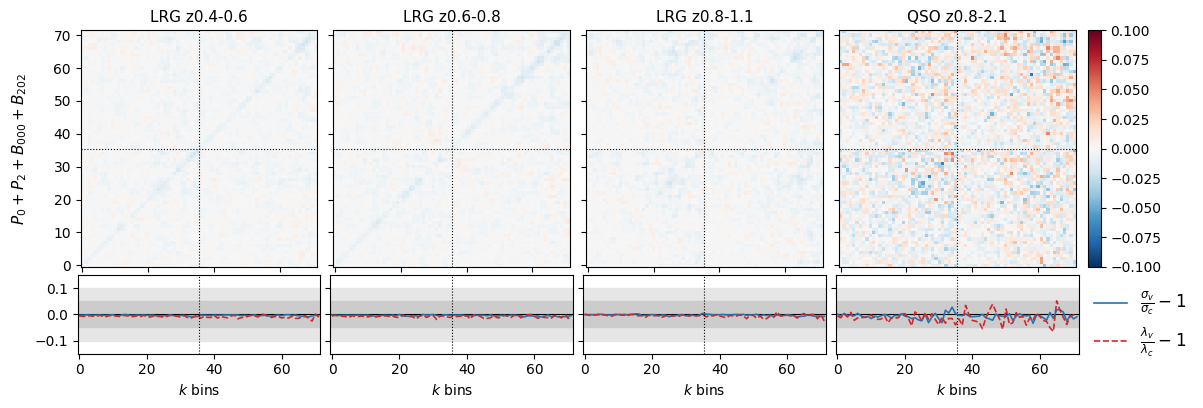

In [115]:
n_bins = len(cov_list)
fig = plt.figure(figsize=(3.2 * n_bins + 0.4, 4.2))
gs = fig.add_gridspec(2, n_bins + 1, height_ratios=(3, 1), width_ratios=[1] * n_bins + [0.05], hspace=0.05, wspace=0.05)
cax = fig.add_subplot(gs[0, -1])
legend_ax = fig.add_subplot(gs[1, -1])
legend_ax.axis('off')

for indc, covs in enumerate(cov_list):
    tracer,_, zrange = tracer_redshifts[indc]
    ax_top = fig.add_subplot(gs[0, indc])
    ax_ratio = fig.add_subplot(gs[1, indc], sharex=ax_top)
    sample_covariance_comparison(
        covs[0], covs[1], title=f'{tracer} z{zrange[0]}-{zrange[1]}',
        ax_cov=ax_top, ax_ratio=ax_ratio, cax=cax, legend_ax=legend_ax,
        add_colorbar=(indc == n_bins - 1), show_legend=(indc == 0),
    )
    if indc > 0:
        ax_top.set_yticklabels([])
        ax_top.set_ylabel('')
        ax_ratio.set_yticklabels([])

fig.align_ylabels()

if save_fig==True:
    fig.savefig(OVERLEAF_DIR+'/plot_cov_comparison.pdf', bbox_inches='tight')